# Proyecto: DaisyWorld Espacio-Temporal 🌼🌎

Este notebook implementa el modelo espacial de Daisyworld. El objetivo es evolucionar de un sistema de Ecuaciones Diferenciales Ordinarias (EDO) a un sistema de Ecuaciones en Derivadas Parciales (EDP), simulando un dominio cuadrado con condiciones de borde periódicas (bucles espacio-temporales para simular un planeta esférico).

Se calcularán y graficarán tanto la evolución temporal de los valores medios globales como la distribución espacial 2D en el estado final. Además de una animación donde se aprecie cómo las flores compiten por territorio, y una animación de la evolución en forma de planeta.

## Importación de librerías y configuración



In [1]:
# Instalación de Cartopy para proyecciones geográficas
!pip install cartopy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

from matplotlib.colors import LinearSegmentedColormap

import matplotlib.animation as animation
from IPython.display import HTML

from tqdm.auto import tqdm  #para visualizar una barra de progreso

import cartopy.crs as ccrs

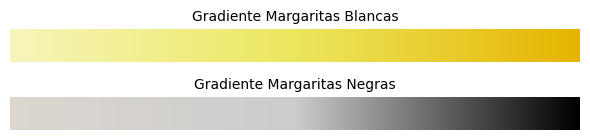

In [3]:
# Configuración para que los gráficos se vean bien en el notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Gradientes customizados para las flores
colors_w = ["#f7f5bc", "#ece75f", "#e6b400"]
flores_blancas = LinearSegmentedColormap.from_list("marg_blancas", colors_w)

colors_b = ["#dcd7d0", "#cccccc", "#000000"]
flores_negras = LinearSegmentedColormap.from_list("marg_negras", colors_b)

# Visualización de los gradientes
gradient = np.linspace(0, 1, 256).reshape(1, -1)
fig, axes = plt.subplots(2, 1, figsize=(6, 1.5))

axes[0].imshow(gradient, aspect='auto', cmap=flores_blancas)
axes[0].set_title('Gradiente Margaritas Blancas', fontsize=10)
axes[0].axis('off')

axes[1].imshow(gradient, aspect='auto', cmap=flores_negras)
axes[1].set_title('Gradiente Margaritas Negras', fontsize=10)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 1. Definición de Parámetros y Dominio
Definimos las constantes físicas y biológicas del modelo, así como la discretización del espacio y el tiempo.

In [4]:
# Parámetros equilibrados para Daisyworld espacial
N = 100
L = 500.0
dx = L / N
dt = 0.05
pasos = 10000      # t = 200

# Ajuste de inercia
C = 50.0

# -------------------------

K = 0.05

# Radiación base (Matriz Latitudinal)
S_nominal = 3000.0
S_base = np.zeros((N, N))
for i in range(N):
    lat_factor = 1.0 - 0.4 * (np.abs(i - N/2) / (N/2))
    S_base[i, :] = S_nominal * lat_factor

S_variacion_amp = 0.05

# --------------------------------------------

sigma = 5.67e-08
A_w = 0.75
A_b = 0.25
A_s = 0.50

# Constantes Biológicas
D_w = 1.0
D_b = 1.0
gamma = 0.03

# Ajuste biológico: Preferencia por el frío
T_opt = 12.5  # Bajamos el óptimo de 22.5 a 12.5

## 2. Operador Laplaciano Periódico
Para la difusión, utilizamos diferencias finitas centradas. La condición de borde periódica (topología toroidal) se implementa de manera eficiente utilizando la función `np.roll` de NumPy, la cual "envuelve" los bordes de la matriz.

El operador aproxima: $$\nabla^2 U \approx \frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2}$$

In [5]:
def laplacian_2d(U, dx):
    """
    Calcula el Laplaciano 2D usando diferencias finitas con condiciones
    de borde periódicas.
    """
    lap_x = (np.roll(U, -1, axis=0) - 2.0 * U + np.roll(U, 1, axis=0)) / (dx**2)
    lap_y = (np.roll(U, -1, axis=1) - 2.0 * U + np.roll(U, 1, axis=1)) / (dx**2)
    return lap_x + lap_y

def tasa_crecimiento(T):
    """
    Se modela como una parábola invertida centrada en T_opt.
    El crecimiento es máximo cuando T = T_opt y disminuye cuando
    la temperatura se aleja de ese valor.

    La función se trunca en cero para evitar tasas negativas.
    """
    beta = 1.0 - 0.003265 * (T - T_opt)**2
    # Evitar tasas negativas usando np.maximum
    return np.maximum(0.0, beta)

## 3. Condiciones Iniciales
Inicializamos el planeta con una temperatura uniforme y densidades bajas de margaritas. Para fomentar la dinámica espacial, introducimos una pequeña perturbación aleatoria en las poblaciones iniciales.

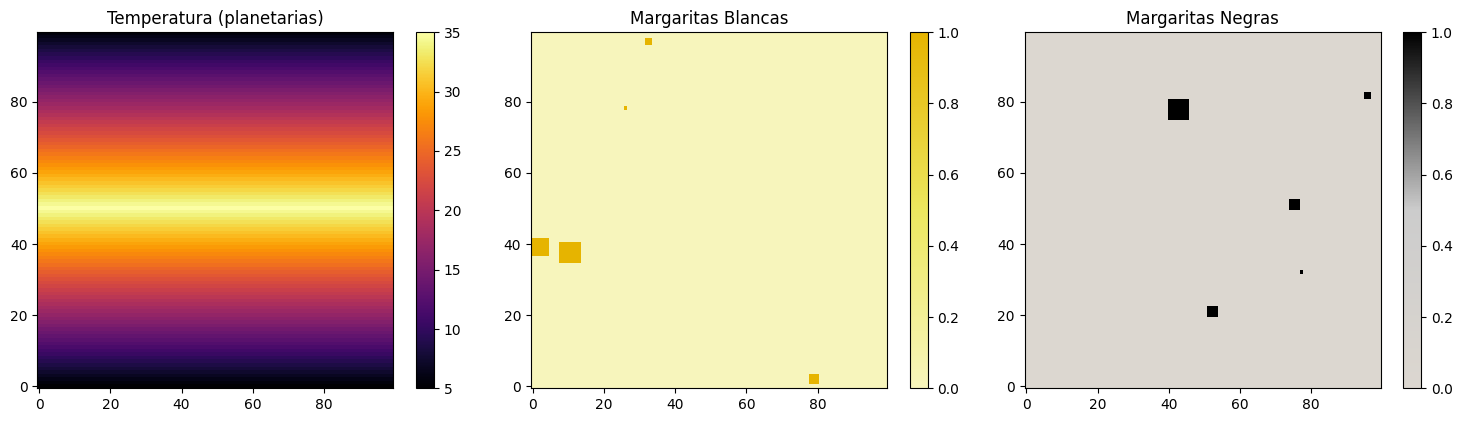

Estado inicial. Modo: planetarias.


In [6]:
# Inicialización del Planeta

# Selecciona el modo de temperatura y ejecuta para preparar el escenario.
modo_inicial = "planetarias" # @param ["homogenea", "ruido", "planetarias", "parches"]

# 1. Funciones auxiliares
def generate_random_patches(alpha_matrix, num_patches, max_patch_size_ratio=0.08, density=0.3):
    """Genera parches biológicos aleatorios."""
    for _ in range(num_patches):
        patch_size = random.randint(1, int(N * max_patch_size_ratio))
        x_start = random.randint(0, N - patch_size)
        y_start = random.randint(0, N - patch_size)
        alpha_matrix[x_start:x_start + patch_size, y_start:y_start + patch_size] = density

# 2. Inicialización de Temperatura
T = np.ones((N, N)) * 20.0
if modo_inicial == "ruido":
    T += (np.random.rand(N, N) - 0.5) * 10.0
elif modo_inicial == "planetarias":
    for i in range(N):
        latitud = np.abs(i - N/2) / (N/2)
        T[i, :] = 35.0 - (latitud * 30.0)
elif modo_inicial == "parches":
    temp_patches = np.zeros((N, N))
    for _ in range(10):
        size = random.randint(5, 15)
        x, y = random.randint(0, N-size), random.randint(0, N-size)
        temp_patches[x:x+size, y:y+size] = random.uniform(-10, 10)
    T += temp_patches

# 3. Inicialización de Margaritas
alpha_w = np.zeros((N, N))
alpha_b = np.zeros((N, N))
generate_random_patches(alpha_w, num_patches=5, max_patch_size_ratio=0.06, density=1)
generate_random_patches(alpha_b, num_patches=5, max_patch_size_ratio=0.06, density=1)

# 4. Visualización del Estado Inicial
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im1 = axes[0].imshow(T, cmap='inferno', origin='lower')
axes[0].set_title(f'Temperatura ({modo_inicial})')
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(alpha_w, cmap=flores_blancas, origin='lower', vmin=0, vmax=1.0)
axes[1].set_title('Margaritas Blancas')
fig.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(alpha_b, cmap=flores_negras, origin='lower', vmin=0, vmax=1.0)
axes[2].set_title('Margaritas Negras')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Estado inicial. Modo: {modo_inicial}.")

## 4. Bucle Principal de Simulación
Resolvemos el sistema acoplado de ecuaciones de reacción-difusión utilizando el método de Euler hacia adelante. En cada iteración, se calcula el albedo local, se aplican los operadores de difusión y se actualiza el estado del sistema. También registramos los promedios globales.

In [7]:
historial_T, historial_w, historial_b = [], [], []
tiempos, T_mean, alpha_w_mean, alpha_b_mean = [], [], [], []
historial_S = []

pasos_por_fotograma = 50

# Nuevos parámetros de competencia
K_competencia = 0.5        # Fuerza de la difusión cruzada
muerte_ruido_amp = 0.005   # Amplitud de la mortalidad aleatoria

# ----------------------------------------

for step in tqdm(range(pasos), desc="Simulando Daisyworld con competencia"):
    # 1. Radiación dinámica
    factor_temporal = 1.0 + S_variacion_amp * np.sin(step * dt * 0.1)
    S_actual = S_base * factor_temporal

    # 2. Albedo y Crecimiento
    A_p = alpha_w * A_w + alpha_b * A_b + (1.0 - alpha_w - alpha_b) * A_s
    espacio_libre = np.clip(1.0 - alpha_w - alpha_b, 0.0, 1.0)
    beta_loc = tasa_crecimiento(T)

    # 3. Operadores espaciales (Laplacianos)
    lap_T = laplacian_2d(T, dx)
    lap_w = laplacian_2d(alpha_w, dx)
    lap_b = laplacian_2d(alpha_b, dx)

    # 4. Mortalidad con ruido aleatorio
    # Crea fluctuaciones locales en la supervivencia
    gamma_variable = gamma + muerte_ruido_amp * np.random.randn(N, N)

    # 5. Ecuaciones de evolución con dif
    T_kelvin = T + 273.15
    dT_dt = (K * lap_T + ((S_actual / 4.0) * (1.0 - A_p) - sigma * (T_kelvin**4))) / C

    # dw/dt = crecimiento + difusión propia - interferencia de la otra especie
    dw_dt = alpha_w * (beta_loc * espacio_libre - gamma_variable) + D_w * (lap_w - K_competencia * lap_b)
    db_dt = alpha_b * (beta_loc * espacio_libre - gamma_variable) + D_b * (lap_b - K_competencia * lap_w)

    # 6. Actualización
    T += dt * dT_dt
    alpha_w += dt * dw_dt
    alpha_b += dt * db_dt

    # Limitadores físicos estrictos
    alpha_w = np.clip(alpha_w, 0.0, 1.0)
    alpha_b = np.clip(alpha_b, 0.0, 1.0)

    if step % pasos_por_fotograma == 0:
        tiempos.append(step * dt)
        T_mean.append(np.mean(T))
        alpha_w_mean.append(np.mean(alpha_w))
        alpha_b_mean.append(np.mean(alpha_b))
        historial_S.append(np.mean(S_actual))
        historial_T.append(T.copy())
        historial_w.append(alpha_w.copy())
        historial_b.append(alpha_b.copy())

print(f"Simulación finalizada.")

Simulando Daisyworld con competencia:   0%|          | 0/10000 [00:00<?, ?it/s]

Simulación finalizada.


## 5. Resultados y Visualización (Valores medios y distribución espacial final)

1. **Gráfico 1D:** Evolución temporal de los valores medios globales (Temperatura y Poblaciones).
2. **Gráfico 2D:** Mapas de calor (Heatmaps) mostrando la distribución espacial final.

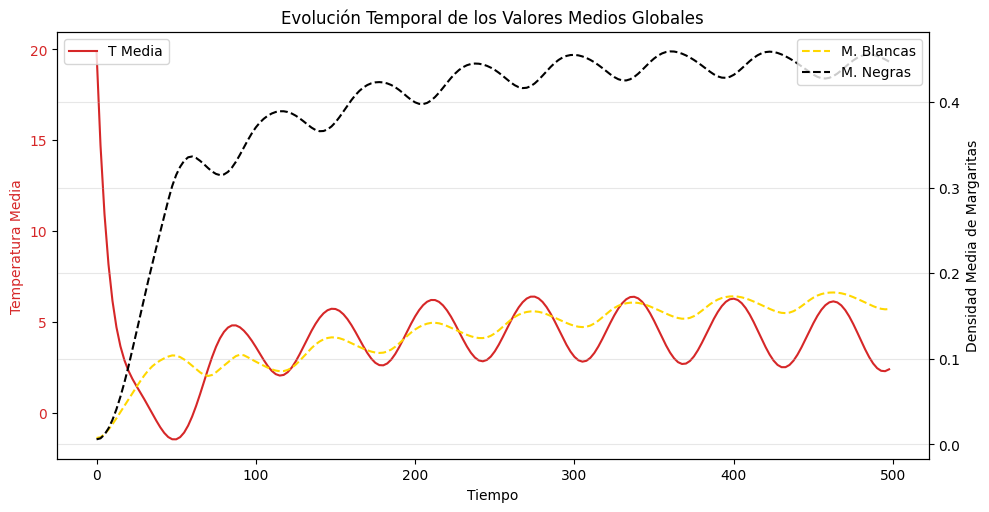

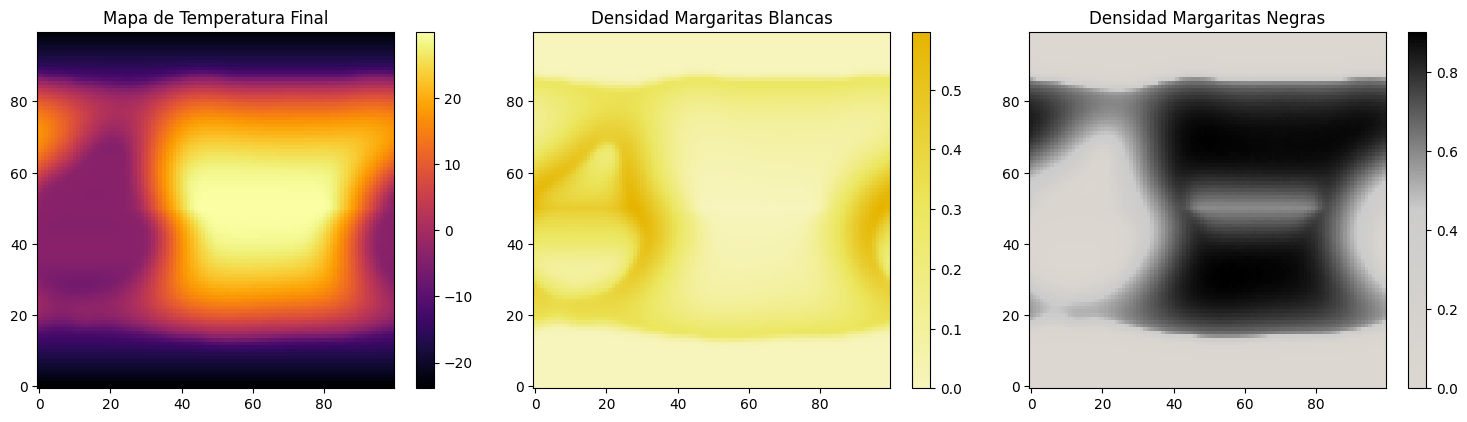

In [8]:
# Gráfico de Evolución Temporal (Valores Medios)
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Tiempo')
ax1.set_ylabel('Temperatura Media', color=color)
ax1.plot(tiempos, T_mean, color=color, label='T Media')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color_w = 'gold'
color_b = 'black'
ax2.set_ylabel('Densidad Media de Margaritas')
ax2.plot(tiempos, alpha_w_mean, color=color_w, label='M. Blancas', linestyle='--')
ax2.plot(tiempos, alpha_b_mean, color=color_b, label='M. Negras', linestyle='--')
ax2.tick_params(axis='y')

fig.tight_layout()
plt.title('Evolución Temporal de los Valores Medios Globales')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Gráficos Espaciales 2D (Estado Final)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mapa de Temperatura
im1 = axes[0].imshow(T, cmap='inferno', origin='lower')
axes[0].set_title('Mapa de Temperatura Final')
fig.colorbar(im1, ax=axes[0])

# Mapa Margaritas Blancas
im2 = axes[1].imshow(alpha_w, cmap=flores_blancas, origin='lower', vmin=0)
axes[1].set_title('Densidad Margaritas Blancas')
fig.colorbar(im2, ax=axes[1])

# Mapa Margaritas Negras
im3 = axes[2].imshow(alpha_b, cmap=flores_negras, origin='lower', vmin=0)
axes[2].set_title('Densidad Margaritas Negras')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 6. Animación (Espacio-Temporal)

In [ ]:
# Configurar la figura para la animación
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Inicializar las imágenes
im_T = axes[0].imshow(historial_T[0], cmap='inferno', origin='lower', vmin=np.min(historial_T), vmax=np.max(historial_T))
im_w = axes[1].imshow(historial_w[0], cmap=flores_blancas, origin='lower', vmin=0, vmax=1.0)
im_b = axes[2].imshow(historial_b[0], cmap=flores_negras, origin='lower', vmin=0, vmax=1.0)

# Títulos
axes[0].set_title('Temperatura')
axes[1].set_title('Margaritas Blancas')
axes[2].set_title('Margaritas Negras')

# Añadir barras de color
fig.colorbar(im_T, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im_w, ax=axes[1], fraction=0.046, pad=0.04)
fig.colorbar(im_b, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

# Barra de progreso
pbar = tqdm(total=len(historial_T), desc="Generando Animación")

def update(frame):
    im_T.set_array(historial_T[frame])
    im_w.set_array(historial_w[frame])
    im_b.set_array(historial_b[frame])
    fig.suptitle(f"Tiempo: {frame * dt * pasos_por_fotograma:.1f}", fontsize=16)
    pbar.update(1)
    return [im_T, im_w, im_b]

# Aumentamos interval de 40 a 60 para una reproducción un poco más lenta
ani = animation.FuncAnimation(fig, update, frames=len(historial_T), interval=60, blit=False)

# Renderizar la animación
anim_html = ani.to_jshtml()
pbar.close()

plt.close()

# Mostrar el reproductor interactivo
HTML(anim_html)

### 💾 Guardar esta simulación como MP4

In [ ]:
# Ejecutar esta celda solo para descargar el video

print("Generando archivo MP4...")
writer = animation.FFMpegWriter(fps=15, metadata=dict(artist='DaisyWorld'), bitrate=1800)
ani.save('daisyworld_sim.mp4', writer=writer)
print("Archivo 'daisyworld_sim.mp4' listo.")

Generando archivo MP4...


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1500x500', '-pix_fmt', 'rgba', '-framerate', '15', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '1800k', '-metadata', 'artist=DaisyWorld', '-y', 'daisyworld_sim.mp4']' returned non-zero exit status 255.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 18.8 MB/s eta 0:00:00


## 7. Animación Planetaria Dual con Indicador Térmico
Visualización comparativa de margaritas blancas y negras sobre el globo, incluyendo el seguimiento de la temperatura media global.


In [ ]:
# Configuración de la figura dual
fig = plt.figure(figsize=(16, 8))

# Proyección para Margaritas Blancas (Izquierda)
ax_w = fig.add_subplot(1, 2, 1, projection=ccrs.Orthographic(0, 0))
ax_w.set_title("Margaritas Blancas", fontsize=14)
ax_w.set_global()
ax_w.coastlines(color='white', alpha=0.2)

# Proyección para Margaritas Negras (Derecha)
ax_b = fig.add_subplot(1, 2, 2, projection=ccrs.Orthographic(0, 0))
ax_b.set_title("Margaritas Negras", fontsize=14)
ax_b.set_global()

# Malla de coordenadas
lons = np.linspace(-180, 180, N)
lats = np.linspace(-90, 90, N)
Lon, Lat = np.meshgrid(lons, lats)

# Inicialización de los meshes
mesh_w = ax_w.pcolormesh(Lon, Lat, historial_w[0], transform=ccrs.PlateCarree(),
                         cmap=flores_blancas, vmin=0, vmax=1.0)
mesh_b = ax_b.pcolormesh(Lon, Lat, historial_b[0], transform=ccrs.PlateCarree(),
                         cmap=flores_negras, vmin=0, vmax=1.0)

# Texto para la temperatura global media
temp_text = fig.text(0.5, 0.05, '', ha='center', fontsize=16, fontweight='bold',
                     bbox=dict(facecolor='red', alpha=0.2, boxstyle='round,pad=0.5'))

pbar_dual = tqdm(total=len(historial_w), desc="Renderizando Globos Duales")

def update_dual_globe(frame):
    # Actualizar coberturas
    mesh_w.set_array(historial_w[frame].flatten())
    mesh_b.set_array(historial_b[frame].flatten())

    # Actualizar texto de temperatura (calculando media del frame actual)
    t_media_actual = np.mean(historial_T[frame])
    temp_text.set_text(f"Temperatura Global Media: {t_media_actual:.2f} °C")

    fig.suptitle(f"Evolución Planetaria - Tiempo: {frame * dt * pasos_por_fotograma:.1f}", fontsize=18)
    pbar_dual.update(1)
    return [mesh_w, mesh_b, temp_text]

# Crear animación
ani_dual = animation.FuncAnimation(fig, update_dual_globe, frames=len(historial_w), interval=80, blit=False)

# Renderizar
dual_globe_html = ani_dual.to_jshtml()
pbar_dual.close()
plt.close()

HTML(dual_globe_html)

### 💾 Guardar Animación Dual

In [ ]:
# Guardar la animación dual como MP4
print("Exportando video de globos duales...")
writer_dual = animation.FFMpegWriter(fps=12, metadata=dict(artist='DaisyWorld Core'), bitrate=2000)
ani_dual.save('daisyworld_dual_globe.mp4', writer=writer_dual)
print("Archivo 'daisyworld_dual_globe.mp4' listo.")

Exportando video de globos duales...
¡Exportación completada! El archivo 'daisyworld_dual_globe.mp4' está listo.
